# EDA

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

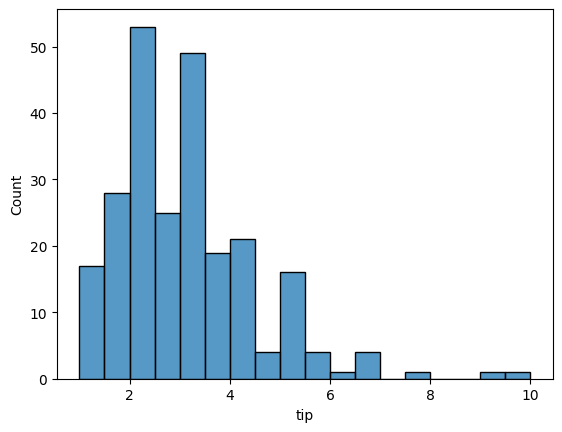

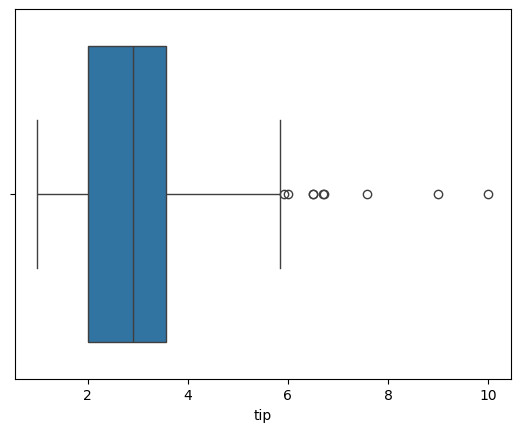

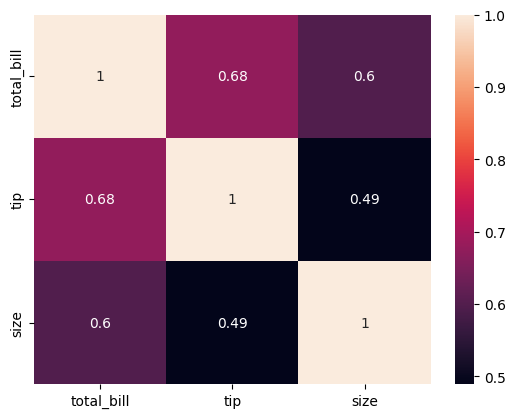

In [2]:
sns.histplot(df["tip"].dropna())
plt.show()

sns.boxplot(x=df["tip"])
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()


# Preprocessing

In [3]:
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [4]:
df = df[['total_bill','tip','sex','smoker','size']]
df = df.dropna()


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("smoker", axis=1)
y = df["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [7]:
df

,total_bill,tip,sex,smoker,size
0,16.99,1.01,0,0,2
1,10.34,1.66,1,0,3
2,21.01,3.50,1,0,3
3,23.68,3.31,1,0,2
4,24.59,3.61,0,0,4
...,...,...,...,...,...
239,29.03,5.92,1,0,3
240,27.18,2.00,0,1,2
241,22.67,2.00,1,1,2
242,17.82,1.75,1,0,2


# Classification



In [8]:
from sklearn.model_selection import train_test_split

X = df.drop("smoker", axis=1)
y = df["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [9]:
y_train

,smoker
228,0
208,1
96,1
167,0
84,0
...,...
106,1
14,0
92,1
179,1


In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)


In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.6530612244897959


In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[29  2]
 [15  3]]


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.94      0.77        31
           1       0.60      0.17      0.26        18

    accuracy                           0.65        49
   macro avg       0.63      0.55      0.52        49
weighted avg       0.64      0.65      0.59        49



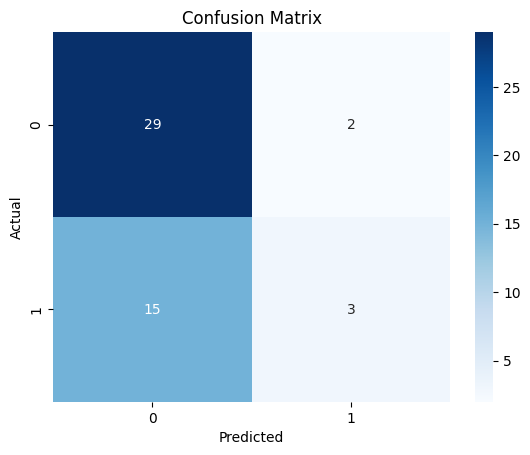

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
